# File to run experiments with various hyperparameters

In [1]:
import pandas as pd
import numpy as np
import torch
import strats
import datetime
import os

print(datetime.datetime.now())


Initializing package . . . 😘
2025-02-19 17:27:32.482734


# Prepare Data

In [2]:
def compute_trimmed_stats(values: pd.Series, low_pct: float, high_pct: float):
    """
    values: 해당 그룹의 value Series
    low_pct, high_pct: 잘라낼 분위수 (예: 0.01, 0.99)
    
    반환: (trimmed_mean, trimmed_std)
    """
    lower_bound = values.quantile(low_pct)
    upper_bound = values.quantile(high_pct)
    trimmed = values[(values >= lower_bound) & (values <= upper_bound)]
    return trimmed.mean(), trimmed.std()

def calculate_all_stats(df: pd.DataFrame):
    # 결과를 담을 리스트
    results = []

    # itemid별로 그룹화
    grouped = df.groupby('itemid')

    for item_id, group in grouped:
        vals = group['value']

        # 1) 전체(아웃라이어 제거 없음) 평균/표준편차
        orig_mean = vals.mean()
        orig_std  = vals.std()

        # 2) 상하위 1% 제거
        mean_1pct, std_1pct = compute_trimmed_stats(vals, 0.01, 0.99)

        # 3) 상하위 3% 제거
        mean_3pct, std_3pct = compute_trimmed_stats(vals, 0.03, 0.97)

        # 4) 상하위 5% 제거
        mean_5pct, std_5pct = compute_trimmed_stats(vals, 0.05, 0.95)

        # 결과 한 줄로 정리
        results.append({
            'itemid': item_id,
            'orig_mean': orig_mean,
            'orig_std': orig_std,
            'mean_1pct': mean_1pct,
            'std_1pct': std_1pct,
            'mean_3pct': mean_3pct,
            'std_3pct': std_3pct,
            'mean_5pct': mean_5pct,
            'std_5pct': std_5pct
        })

    # 리스트를 DataFrame으로
    df_stats = pd.DataFrame(results)
    return df_stats

In [4]:
eicu_static = pd.read_feather('eicu_data_static.feather')
data_vital = pd.read_feather('eicu_data_vital.feather').rename(columns={'valuenum' : 'value'})
data_lab = pd.read_feather('eicu_data_lab.feather').rename(columns={'valuenum' : 'value'})
data_treatment = pd.read_feather('eicu_data_treatment.feather').rename(columns={'valuenum' : 'value'})

In [ ]:

# # Must be fixed!!!!!!!!
# def process_static(static):
#     # Treat only in-hospital death
#     static.loc[static['hospital_expire_flag'] == 0, 'deathtime'] = None
#     print(len(static[static['outtime'] >= static['deathtime']]))
#     static = static.loc[:,['hadm_id', 'deathtime']]
#     static = static.rename(columns={'hadm_id': 'hadm_id', 'deathtime' : 'death_offset'})
#     unique_static_ids = static['hadm_id'].unique()
#     return static, unique_static_ids

# eicu_outcome, eicu_ids = process_static(mieicu_staticmic_static)
eicu_ids = 

data_vital = pd.read_feather('eicu_data_vital.feather').rename(columns={'valuenum' : 'value'})
data_lab = pd.read_feather('eicu_data_lab.feather').rename(columns={'valuenum' : 'value'})
data_treatment = pd.read_feather('eicu_data_treatment.feather').rename(columns={'valuenum' : 'value'})

data = pd.concat([data_vital, data_lab, data_treatment])

# Factorize the 'item' column and get the mapping
encoded_total, actual_class_total = pd.factorize(data['itemid'])
data.loc[:,'itemid'] = encoded_total.astype(int)
data['itemid'] = pd.to_numeric(data['itemid'], errors='coerce')

data = data.dropna(subset=['value'])
data_stats = calculate_all_stats(data)

item_dict_total = dict(zip(actual_class_total, range(len(actual_class_total))))
emb_idx_total = len(item_dict_total)

# 재현성 유지를 위해 seed를 고정하고 섞습니다.
np.random.seed(9871)
np.random.shuffle(eicu_ids)

# 예: 80%를 train, 나머지를 valid로 사용
train_size = int(len(eicu_ids) * 0.6)
valid_size = int(len(eicu_ids) * 0.8)
train_hadm_ids = eicu_ids[:train_size]
valid_hadm_ids = eicu_ids[train_size:valid_size]
test_hadm_ids = eicu_ids[valid_size:]

train_final_ids = train_hadm_ids
valid_final_ids = valid_hadm_ids
test_final_ids = test_hadm_ids

# # (A) death_offset이 존재하는 hadm_id 목록
# hadm_with_death_offset = set(
#     mimic_outcome.loc[~mimic_outcome['death_offset'].isna(), 'hadm_id']
# )

# # (B) Train 아이디 중, death_offset 존재 vs 미존재
# train_hadm_set = set(train_hadm_ids)
# train_hadm_with_death = train_hadm_set & hadm_with_death_offset
# train_hadm_no_death = list(train_hadm_set - hadm_with_death_offset)

# # (C) no_death 중 40%만 샘플링
# sample_count = int(len(train_hadm_no_death) * 0.4)
# np.random.shuffle(train_hadm_no_death)

# train_hadm_no_death_sampled = train_hadm_no_death[:sample_count]

# # 최종 Train 아이디
# train_final_ids = set(train_hadm_with_death) | set(train_hadm_no_death_sampled)

# # Same for validation
# valid_hadm_set = set(valid_hadm_ids)
# valid_hadm_with_death = valid_hadm_set & hadm_with_death_offset
# valid_hadm_no_death = list(valid_hadm_set - hadm_with_death_offset)

# sample_count = int(len(valid_hadm_no_death) * 0.4)
# np.random.shuffle(valid_hadm_no_death)

# valid_hadm_no_death_sampled = valid_hadm_no_death[:sample_count]
# valid_final_ids = set(valid_hadm_with_death) | set(valid_hadm_no_death_sampled)

# # Also for test...
# test_hadm_set = set(test_hadm_ids)
# test_hadm_with_death = test_hadm_set & hadm_with_death_offset
# test_hadm_no_death = list(test_hadm_set - hadm_with_death_offset)

# sample_count = int(len(test_hadm_no_death) * 0.4)
# np.random.shuffle(test_hadm_no_death)

# test_hadm_no_death_sampled = test_hadm_no_death[:sample_count]
# test_final_ids = set(test_hadm_with_death) | set(test_hadm_no_death_sampled)




# (D) 최종 DF
train_df = data[data['hadm_id'].isin(train_final_ids)].copy().reset_index(drop=True)
valid_df = data[data['hadm_id'].isin(valid_final_ids)].copy().reset_index(drop=True)
test_df = data[data['hadm_id'].isin(test_final_ids)].copy().reset_index(drop=True)

train_outcome_df = eicu_outcome[eicu_outcome['hadm_id'].isin(train_final_ids)].copy()
valid_outcome_df = eicu_outcome[eicu_outcome['hadm_id'].isin(valid_final_ids)].copy()
test_outcome_df = eicu_outcome[eicu_outcome['hadm_id'].isin(test_final_ids)].copy()
print(datetime.datetime.now())

scaler_dict, train_loader, valid_loader, test_loader, emb_idx = strats.mimic_eicu_create_loaders(train_df, valid_df, test_df,
                                                                                     train_outcome_df, valid_outcome_df, test_outcome_df,
                                                                                     batch_size=64, mask_length=720, mask_segment_count=4, query_type='initial', trim_percentile=0.01)
print(datetime.datetime.now())
# scaler_dynamic_dict, train_dynamic_loader, valid_dynamic_loader, test_dynamic_loader, emb_idx = strats.mimic_eicu_create_loaders(train_df, valid_df, test_df,
#                                                                                      train_outcome_df, valid_outcome_df, test_outcome_df,
#                                                                                      batch_size=32, mask_length=600, mask_segment_count=4, query_type='dynamic')

21
2025-02-06 14:47:11.926590
[Auto-detect Binary ItemIDs] Start...
[Auto-detect Binary ItemIDs] Found 14 itemids: {18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31}
[Trimming] Completed. Remaining train size = 25993482, valid size = 8801979, test size = 8740088
[Scaling] StandardScaler enabled.
[Scaling] Completed.
[TimeSeriesDataset] Created 27159 samples.  Death=1: 1040 samples.
[TimeSeriesDataset] Created 9053 samples.  Death=1: 334 samples.
[TimeSeriesDataset] Created 9054 samples.  Death=1: 339 samples.
Embedding index/pad_id = 32
2025-02-06 14:54:39.219157


In [ ]:
data = data_vital

# Factorize the 'item' column and get the mapping
encoded_vital, actual_class_vital = pd.factorize(data['itemid'])
data.loc[:,'itemid'] = encoded_vital.astype(int)
data['itemid'] = pd.to_numeric(data['itemid'], errors='coerce')

data = data.dropna(subset=['value'])

item_dict_vital = dict(zip(actual_class_vital, range(len(actual_class_vital))))
emb_idx_vital = len(item_dict_vital)

train_df = data[data['hadm_id'].isin(train_final_ids)].copy().reset_index(drop=True)
valid_df = data[data['hadm_id'].isin(valid_final_ids)].copy().reset_index(drop=True)
test_df = data[data['hadm_id'].isin(test_final_ids)].copy().reset_index(drop=True)
print(datetime.datetime.now())

scaler_vital_dict, train_vital_loader, valid_vital_loader, test_vital_loader, emb_vital_idx = strats.mimic_eicu_create_loaders(train_df, valid_df, test_df,
                                                                                     train_outcome_df, valid_outcome_df, test_outcome_df,
                                                                                     batch_size=64, mask_length=720, mask_segment_count=4, query_type='initial', trim_percentile=0.01)
print('[Finished] Vital samples created')

2025-02-06 14:54:41.550626
[Auto-detect Binary ItemIDs] Start...
[Auto-detect Binary ItemIDs] Found 0 itemids: set()
[Trimming] Completed. Remaining train size = 9746235, valid size = 3305014, test size = 3252873
[Scaling] StandardScaler enabled.
[Scaling] Completed.
[TimeSeriesDataset] Created 27133 samples.  Death=1: 1035 samples.
[TimeSeriesDataset] Created 9043 samples.  Death=1: 333 samples.
[TimeSeriesDataset] Created 9050 samples.  Death=1: 339 samples.
Embedding index/pad_id = 5
[Finished] Vital samples created


In [ ]:
data = data_lab

# Factorize the 'item' column and get the mapping
encoded_lab, actual_class_lab = pd.factorize(data['itemid'])
data.loc[:,'itemid'] = encoded_lab.astype(int)
data['itemid'] = pd.to_numeric(data['itemid'], errors='coerce')

data = data.dropna(subset=['value'])

item_dict_lab = dict(zip(actual_class_lab, range(len(actual_class_lab))))
emb_idx_lab = len(item_dict_lab)

train_df = data[data['hadm_id'].isin(train_final_ids)].copy().reset_index(drop=True)
valid_df = data[data['hadm_id'].isin(valid_final_ids)].copy().reset_index(drop=True)
test_df = data[data['hadm_id'].isin(test_final_ids)].copy().reset_index(drop=True)
print(datetime.datetime.now())

scaler_lab_dict, train_lab_loader, valid_lab_loader, test_lab_loader, emb_lab_idx = strats.mimic_eicu_create_loaders(train_df, valid_df, test_df,
                                                                                     train_outcome_df, valid_outcome_df, test_outcome_df,
                                                                                     batch_size=64, mask_length=720, mask_segment_count=4, query_type='initial', trim_percentile=0.01)
print('[Finished] Lab samples created')

2025-02-06 13:02:36.164995
[Auto-detect Binary ItemIDs] Start...
[Auto-detect Binary ItemIDs] Found 0 itemids: set()
[Trimming] Completed. Remaining train size = 4370015, valid size = 1462979, test size = 1470534
[Scaling] StandardScaler enabled.
[Scaling] Completed.
[TimeSeriesDataset] Created 11476 samples.  Death=1: 1035 samples.
[TimeSeriesDataset] Created 3814 samples.  Death=1: 332 samples.
[TimeSeriesDataset] Created 3818 samples.  Death=1: 335 samples.
Embedding index/pad_id = 13
[Finished] Lab samples created


In [ ]:
data = data_treatment

# Factorize the 'item' column and get the mapping
encoded_treatment, actual_class_treatment = pd.factorize(data['itemid'])
data.loc[:,'itemid'] = encoded_treatment.astype(int)
data['itemid'] = pd.to_numeric(data['itemid'], errors='coerce')

data = data.dropna(subset=['value'])

item_dict_treatment = dict(zip(actual_class_treatment, range(len(actual_class_treatment))))
emb_idx_treatment = len(item_dict_treatment)

train_df = data[data['hadm_id'].isin(train_final_ids)].copy().reset_index(drop=True)
valid_df = data[data['hadm_id'].isin(valid_final_ids)].copy().reset_index(drop=True)
test_df = data[data['hadm_id'].isin(test_final_ids)].copy().reset_index(drop=True)
print(datetime.datetime.now())

scaler_treatment_dict, train_treatment_loader, valid_treatment_loader, test_treatment_loader, emb_treatment_idx = strats.mimic_eicu_create_loaders(train_df, valid_df, test_df,
                                                                                     train_outcome_df, valid_outcome_df, test_outcome_df,
                                                                                     batch_size=64, mask_length=720, mask_segment_count=4, query_type='initial', scale=False, trim_percentile=0.01)
print('[Finished] Treatment samples created')

2025-02-06 13:03:49.485802
[Auto-detect Binary ItemIDs] Start...
[Auto-detect Binary ItemIDs] Found 14 itemids: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13}
[Trimming] Completed. Remaining train size = 2658762, valid size = 889950, test size = 888390
[Scaling] Skipped.
[TimeSeriesDataset] Created 10379 samples.  Death=1: 912 samples.
[TimeSeriesDataset] Created 3424 samples.  Death=1: 292 samples.
[TimeSeriesDataset] Created 3441 samples.  Death=1: 306 samples.
Embedding index/pad_id = 14
[Finished] Treatment samples created


# Experiments

### Define class

In [ ]:
class STraTSExperiment:
    """
    STraTS 모델 전체 파이프라인을 하나의 클래스로 묶어,
    - 모델 파라미터 설정
    - Pretrain
    - Pretrain Validate
    - Downstream Train
    - Evaluate
    등을 메서드로 구성.
    """
    def __init__(self,
                 emb_idx,
                 train_loader,
                 valid_loader,
                 test_loader,
                 version=None,
                 # 모델 관련 파라미터
                 num_heads=4,
                 num_layers=2,
                 ff_dim=64,
                 embed_dim=32,
                 dropout=0.2,
                 time_activation='relu',
                 value_activation='tanh',
                 final_emb_type='cls',
                 fusion_emb_weight=0.5,
                 final_emb_weight=0.5,
                 # 학습 관련 파라미터
                 patience=30,
                 device=None):
        """
        emb_idx: 최종 임베딩 개수 (num_features)
        version: 모델/결과 파일 저장에 쓸 버전 이름 (기본값: 날짜_0 형태)
        기타 모델 하이퍼파라미터들...
        """
        # 버전 설정
        if version is None:
            # 날짜_0 형태 기본
            ver = 0
            today = datetime.date.today().isoformat()  # 예: '2024-01-05'
            version = f'{today}_{ver}'
        self.version = version
        self.train_loader = train_loader
        self.valid_loader = valid_loader
        self.test_loader = test_loader

        # device
        if device is None:
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.device = device

        # 모델 생성
        self.model = strats.STraTSModel(
            num_features=emb_idx,
            embed_dim=embed_dim,
            num_heads=num_heads,
            num_blocks=num_layers,
            ff_dim=ff_dim,
            dropout=dropout,
            time_activation=time_activation,
            value_activation=value_activation,
            final_emb_type=final_emb_type,
            fusion_emb_weight=fusion_emb_weight,
            final_emb_weight=final_emb_weight
        ).to(self.device)

        # 학습 관련 파라미터
        self.patience = patience

        # optimizer (사용자가 바꿀 수 있도록)

        print(f"[STraTSExperiment] Initialized with version={self.version}, device={self.device}.")

    def pretrain(self, epochs=1000,
                 model_save_dir='./models_pt', learning_rate=1e-3):
        """
        Pretrain the model (masking-based).
        """
        # ensure save dir
        os.makedirs(model_save_dir, exist_ok=True)

        # pretrain
        print("[STraTSExperiment] Starting pretrain...")
        save_path = os.path.join(model_save_dir, f'pretrained_model_{self.version}.pt')

        optimizer = torch.optim.AdamW(self.model.parameters(), lr=learning_rate)

        strats.pretrain_model(model=self.model,
                              train_loader=self.train_loader,
                              valid_loader=self.valid_loader,
                              epochs=epochs,
                              optimizer=optimizer,
                              device=self.device,
                              patience=self.patience,
                              model_save_path=save_path)

        print("[STraTSExperiment] Pretrain finished.")
        print(f"[STraTSExperiment] Best pretrain model saved at: {save_path}")
        self.model.load_state_dict(torch.load(save_path)) # Load best pretrain model

    def validate_pretrain(self, result_save_dir='./model_results'):
        """
        Validate pretrain results -> CSV
        """
        os.makedirs(result_save_dir, exist_ok=True)
        # 로드된 self.model 이용
        df_pretrain_results = strats.validate_model(self.model, self.valid_loader, device=self.device)
        # emb_idx에 해당하는 패딩/불필요 row 제거
        df_pretrain_results = df_pretrain_results.loc[df_pretrain_results['Variable'] != emb_idx]
        # CSV 저장
        save_path = os.path.join(result_save_dir, f'pretrained_result_{self.version}.csv')
        df_pretrain_results.to_csv(save_path, index=False)
        print(f"[STraTSExperiment] Pretrain validation result saved to {save_path}")

    def load_pretrained_model(self, model_load_path):
        """
        명시적으로 pretrained 모델을 로드하고 싶다면 호출
        """
        self.model.load_state_dict(torch.load(model_load_path, map_location=self.device))
        print(f"[STraTSExperiment] Loaded pretrained model from {model_load_path}")

    def train_downstream(self,
                         epochs=1000,
                         freeze=False,
                         model_save_dir='./models_pt',
                         result_save_dir='./model_results',
                         learning_rate = 1e-4):
        """
        Downstream train (fine-tuning or freeze)
        - freeze=True => pretrain 부분 고정
        - use_loss => ['death'], ['saps', 'sofa', 'death'] 등
        """
        os.makedirs(model_save_dir, exist_ok=True)
        os.makedirs(result_save_dir, exist_ok=True)
        save_path = os.path.join(model_save_dir, f'downstream_model_{self.version}.pt')

        optimizer = torch.optim.AdamW(self.model.parameters(), lr=learning_rate)


        print("[STraTSExperiment] Starting downstream training...")
        df_downstream_loss = strats.train_model(
            model=self.model,
            train_loader=self.train_loader,
            valid_loader=self.valid_loader,
            epochs=epochs,
            optimizer=optimizer,
            device=self.device,
            patience=self.patience,
            freeze=freeze,
            model_save_path=save_path,
        )
        # CSV로 저장
        csv_path = os.path.join(result_save_dir, f'downstream_loss_{self.version}.csv')
        df_downstream_loss.to_csv(csv_path, index=False)
        print("[STraTSExperiment] Downstream training finished.")
        print(f"[STraTSExperiment] Best downstream model saved at: {save_path}")
        print(f"[STraTSExperiment] Training loss saved to {csv_path}")
        self.model.load_state_dict(torch.load(save_path))

    def load_downstream_model(self, model_load_path):
        """
        명시적으로 downstream 모델 로드
        """
        self.model.load_state_dict(torch.load(model_load_path, map_location=self.device))
        print(f"[STraTSExperiment] Loaded downstream model from {model_load_path}")

    def evaluate(self, result_save_dir='./model_results'):
        """
        Evaluate the final model on test set => metrics (AUROC, AUPRC, etc.)
        Also save the (hadm_id, query_time, embedding) data to CSV.
        """
        os.makedirs(result_save_dir, exist_ok=True)

        # 이 evaluate_model 함수는 수정된 버전으로,
        # (metrics, test_embeddings)를 리턴한다고 가정
        metrics, test_embeddings = strats.evaluate_model(self.model, self.test_loader, self.device)

        # 1) 성능 지표 출력
        print("[STraTSExperiment] Test Metrics:")
        for k, v in metrics.items():
            print(f"  {k}: {v:.4f}")

        # 2) 임베딩 저장
        # test_embeddings = {
        #   'hadm_id': np.array([...]),        # shape (N,)
        #   'query_time': np.array([...]),     # shape (N,)
        #   'embedding': np.array([...])       # shape (N, embed_dim)
        # }
        hadm_ids = test_embeddings['hadm_id']
        query_times = test_embeddings['query_time']
        emb_array = test_embeddings['embedding']  # shape=(N, embed_dim)
        num_samples, embed_dim = emb_array.shape

        # 임베딩을 pandas DataFrame으로 변환
        # 각 row: hadm_id, query_time, emb_0, emb_1, ... emb_(embed_dim-1)
        embed_df = pd.DataFrame({
            'hadm_id': hadm_ids,
            'query_time': query_times
        })
        for i in range(embed_dim):
            embed_df[f'emb_{i}'] = emb_array[:, i]

        # CSV로 저장
        emb_save_path = os.path.join(result_save_dir, f'test_embedding_{self.version}.csv')
        embed_df.to_csv(emb_save_path, index=False)


        # Train embeddings
        _, train_embedding = strats.evaluate_model(self.model, self.train_loader, self.device)

        hadm_ids = train_embedding['hadm_id']
        query_times = train_embedding['query_time']
        emb_array = train_embedding['embedding']  # shape=(N, embed_dim)
        num_samples, embed_dim = emb_array.shape

        embed_df = pd.DataFrame({
            'hadm_id': hadm_ids,
            'query_time': query_times
        })
        for i in range(embed_dim):
            embed_df[f'emb_{i}'] = emb_array[:, i]

        # CSV로 저장
        emb_save_path = os.path.join(result_save_dir, f'train_embedding_{self.version}.csv')
        embed_df.to_csv(emb_save_path, index=False)

        # Valid...
        _, valid_embedding = strats.evaluate_model(self.model, self.valid_loader, self.device)

        hadm_ids = valid_embedding['hadm_id']
        query_times = valid_embedding['query_time']
        emb_array = valid_embedding['embedding']  # shape=(N, embed_dim)
        num_samples, embed_dim = emb_array.shape

        embed_df = pd.DataFrame({
            'hadm_id': hadm_ids,
            'query_time': query_times
        })
        for i in range(embed_dim):
            embed_df[f'emb_{i}'] = emb_array[:, i]

        # CSV로 저장
        emb_save_path = os.path.join(result_save_dir, f'valid_embedding_{self.version}.csv')
        embed_df.to_csv(emb_save_path, index=False)

        print(f"[STraTSExperiment] Saved embeddings to {emb_save_path}")


        return metrics
    

### Task 0

[STraTSExperiment] Initialized with version=mimic_initial_48_cls_undersample, device=cuda.
[STraTSExperiment] Starting pretrain...


[Pretrain] Epoch [1/30] - Training:   0%|          | 0/180 [00:00<?, ?it/s]

[Pretrain] Epoch [1/30] - Validation:   0%|          | 0/60 [00:00<?, ?it/s]

[Pretrain] Epoch 1: Train Loss = 0.6865, Valid Loss = 0.5750


[Pretrain] Epoch [2/30] - Training:   0%|          | 0/180 [00:00<?, ?it/s]

...

[Pretrain] Epoch [29/30] - Validation:   0%|          | 0/60 [00:00<?, ?it/s]

[Pretrain] Epoch 29: Train Loss = 0.3846, Valid Loss = 0.3515


[Pretrain] Epoch [30/30] - Training:   0%|          | 0/180 [00:00<?, ?it/s]

[Pretrain] Epoch [30/30] - Validation:   0%|          | 0/60 [00:00<?, ?it/s]

[Pretrain] Epoch 30: Train Loss = 0.3831, Valid Loss = 0.3522


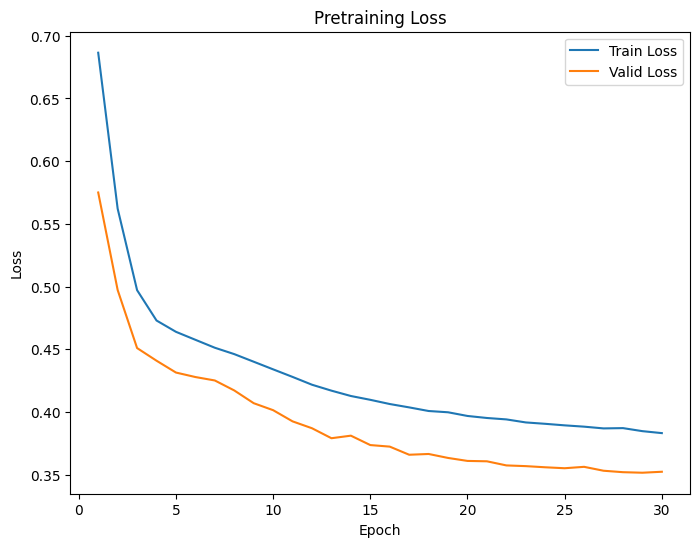

[STraTSExperiment] Pretrain finished.
[STraTSExperiment] Best pretrain model saved at: ./models_pt\pretrained_model_mimic_initial_48_cls_undersample.pt


In [ ]:
# CLS final_emb
exp_0 = STraTSExperiment(
    emb_idx=emb_idx,            # num_features
    train_loader=train_loader,
    valid_loader=valid_loader,
    test_loader=test_loader,
    version='trained_eicu_initial_48_fusion_full',           # None이면 자동으로 날짜_0 형태
    num_heads=4,
    num_layers=2,
    ff_dim=64,
    embed_dim=128,
    dropout=0.2,
    time_activation='relu',
    value_activation='tanh',
    final_emb_type='fusion',
    fusion_emb_weight=0.5,
    final_emb_weight=0.5,
    patience=7
)

exp_0.load_downstream_model('./models_pt/downstream_model_mimic_initial_48_fusion_full.pt')

# Load model and evaluate
exp_0.evaluate()

[STraTSExperiment] Pretrain validation result saved to ./model_results\pretrained_result_mimic_initial_48_cls_undersample.csv
[STraTSExperiment] Starting downstream training...


[Downstream] Epoch [1/1000] - Training:   0%|          | 0/180 [00:00<?, ?it/s]

[Downstream] Epoch [1/1000] - Validation:   0%|          | 0/60 [00:00<?, ?it/s]

[Epoch 1] Train Loss=0.4855, Valid Loss=0.3616, Valid AUROC=0.6852, AUPRC=0.1966


[Downstream] Epoch [2/1000] - Training:   0%|          | 0/180 [00:00<?, ?it/s]

...

[Downstream] Epoch [46/1000] - Validation:   0%|          | 0/60 [00:00<?, ?it/s]

[Epoch 46] Train Loss=0.2159, Valid Loss=0.2209, Valid AUROC=0.8605, AUPRC=0.4112


[Downstream] Epoch [47/1000] - Training:   0%|          | 0/180 [00:00<?, ?it/s]

[Downstream] Epoch [47/1000] - Validation:   0%|          | 0/60 [00:00<?, ?it/s]

[Epoch 47] Train Loss=0.2140, Valid Loss=0.2238, Valid AUROC=0.8581, AUPRC=0.4040
Early stopping triggered (downstream).


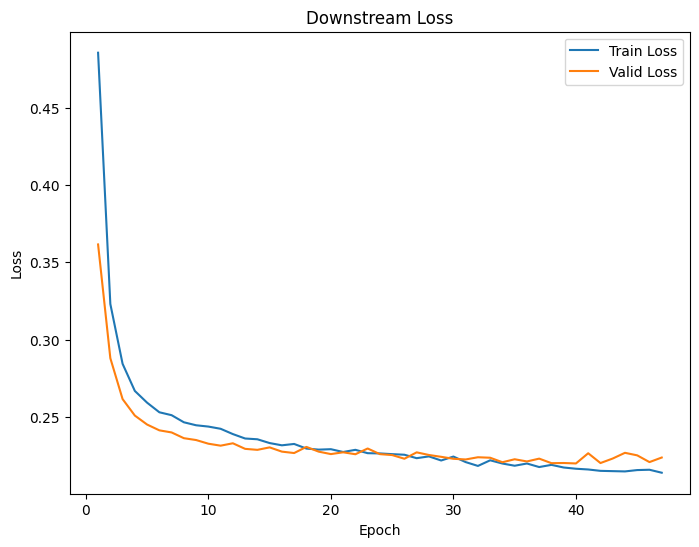

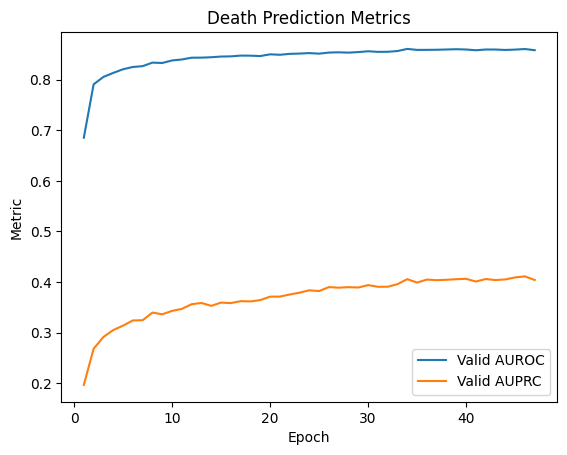

[STraTSExperiment] Downstream training finished.
[STraTSExperiment] Best downstream model saved at: ./models_pt\downstream_model_mimic_initial_48_cls_undersample.pt
[STraTSExperiment] Training loss saved to ./model_results\downstream_loss_mimic_initial_48_cls_undersample.csv
[STraTSExperiment] Test Metrics:
  AUROC: 0.8510
  AUPRC: 0.4104
  Precision: 0.5413
  Recall: 0.1740
  F1: 0.2634
  Accuracy: 0.9137
[STraTSExperiment] Saved embeddings to ./model_results\test_embedding_mimic_initial_48_cls_undersample.csv


In [ ]:
exp_1 = STraTSExperiment(
    emb_idx=emb_idx,            # num_features
    train_loader=train_loader,
    valid_loader=valid_loader,
    test_loader=test_loader,
    version='trained_eicu_vital_48_fusion_full',           # None이면 자동으로 날짜_0 형태
    num_heads=4,
    num_layers=2,
    ff_dim=64,
    embed_dim=32,
    dropout=0.2,
    time_activation='relu',
    value_activation='tanh',
    final_emb_type='fusion',
    fusion_emb_weight=0.5,
    final_emb_weight=0.5,
    patience=7
)

exp_1.load_downstream_model('./models_pt/downstream_model_mimic_vital_48_fusion_full.pt')

# Load model and evaluate
exp_1.evaluate()

In [ ]:
exp_2 = STraTSExperiment(
    emb_idx=emb_idx,            # num_features
    train_loader=train_loader,
    valid_loader=valid_loader,
    test_loader=test_loader,
    version='trained_eicu_lab_48_fusion_full',           # None이면 자동으로 날짜_0 형태
    num_heads=4,
    num_layers=2,
    ff_dim=64,
    embed_dim=32,
    dropout=0.2,
    time_activation='relu',
    value_activation='tanh',
    final_emb_type='fusion',
    fusion_emb_weight=0.5,
    final_emb_weight=0.5,
    patience=7
)

exp_2.load_downstream_model('./models_pt/downstream_model_mimic_lab_48_fusion_full.pt')

# Load model and evaluate
exp_2.evaluate()

In [ ]:
exp_3 = STraTSExperiment(
    emb_idx=emb_idx,            # num_features
    train_loader=train_loader,
    valid_loader=valid_loader,
    test_loader=test_loader,
    version='trained_eicu_treatment_48_fusion_full',           # None이면 자동으로 날짜_0 형태
    num_heads=4,
    num_layers=2,
    ff_dim=64,
    embed_dim=32,
    dropout=0.2,
    time_activation='relu',
    value_activation='tanh',
    final_emb_type='fusion',
    fusion_emb_weight=0.5,
    final_emb_weight=0.5,
    patience=7
)

exp_3.load_downstream_model('./models_pt/downstream_model_mimic_treatment_48_fusion_full.pt')

# Load model and evaluate
exp_3.evaluate()